Лабораторна робота №1
# "Лінійна регресія, оптимізація та статистичний аналіз"

**Мета:** Зрозуміти архітектуру лінійної регресії, навчитися самостійно реалізовувати алгоритми оптимізації, обирати інформативні ознаки, обчислювати метрики якості та перевіряти статистичні припущення моделі.

**Використаний датасет**: Ames Housing Dataset
- **Цільова змінна**: SalePrice(числова, регресія).
- **Числові ознаки**: LotArea, GrLiveArea, YearBuilt тощо.
- **Категоріальні ознаки**: Neighborhood, BldgType, HouseStyle, KitchenQual тощо.

## Етап 1. Дослідження даних (EDA), відбір ознак та попередня обробка 

### Дослідження даних

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("./data/AmesHousing.csv")


Dataset shape: (2930, 82)


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900



--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   objec

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2930.00000,2.930000e+03,2930.000000,2440.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2907.000000,...,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,1465.50000,7.144645e+08,57.387372,69.224590,10147.921843,6.094881,5.563140,1971.356314,1984.266553,101.896801,...,93.751877,47.533447,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068
std,845.96247,1.887308e+08,42.638025,23.365335,7880.017759,1.411026,1.111537,30.245361,20.860286,179.112611,...,126.361562,67.483400,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357
min,1.00000,5.263011e+08,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000
25%,733.25000,5.284770e+08,20.000000,58.000000,7440.250000,5.000000,5.000000,1954.000000,1965.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000
50%,1465.50000,5.354536e+08,50.000000,68.000000,9436.500000,6.000000,5.000000,1973.000000,1993.000000,0.000000,...,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000
75%,2197.75000,9.071811e+08,70.000000,80.000000,11555.250000,7.000000,6.000000,2001.000000,2004.000000,164.000000,...,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000
max,2930.00000,1.007100e+09,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,...,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000



--- Categorical Features Statistics ---


,MS Zoning,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,...,Garage Type,Garage Finish,Garage Qual,Garage Cond,Paved Drive,Pool QC,Fence,Misc Feature,Sale Type,Sale Condition
count,2930,2930,198,2930,2930,2930,2930,2930,2930,2930,...,2773,2771,2771,2771,2930,13,572,106,2930,2930
unique,7,2,2,4,4,3,5,3,28,9,...,6,3,5,5,3,4,4,5,10,6
top,RL,Pave,Grvl,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,...,Attchd,Unf,TA,TA,Y,Ex,MnPrv,Shed,WD,Normal
freq,2273,2918,120,1859,2633,2927,2140,2789,443,2522,...,1731,1231,2615,2665,2652,4,330,95,2536,2413



--- Missing Values Count (Top 15) ---
Pool QC           2917
Misc Feature      2824
Alley             2732
Fence             2358
Mas Vnr Type      1775
Fireplace Qu      1422
Lot Frontage       490
Garage Qual        159
Garage Cond        159
Garage Yr Blt      159
Garage Finish      159
Garage Type        157
Bsmt Exposure       83
BsmtFin Type 2      81
Bsmt Cond           80
dtype: int64


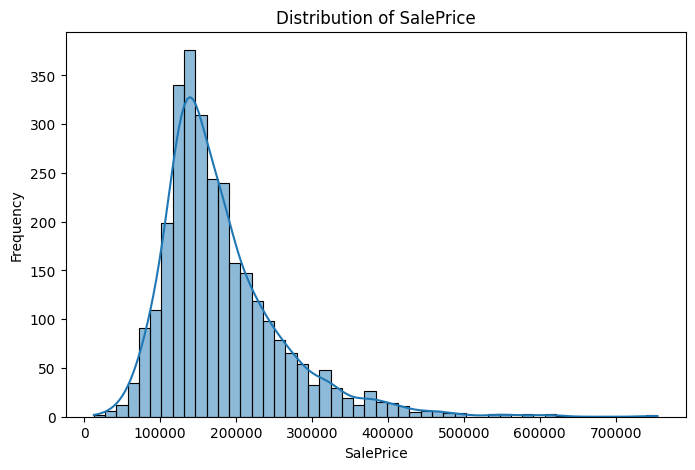

In [ ]:
# Структура датасету
print("Dataset shape:", df.shape)
display(df.head())

# Типи ознак
print("\n--- Dataset Info ---")
df.info()

# Статистичні характеристики
# для числових
print("\n--- Numerical Features Statistics ---")
display(df.describe())

# для категоріальних
print("\n--- Categorical Features Statistics ---")
display(df.describe(include=['object']))

# Пропущені значення
print("\n--- Missing Values Count (Top 15) ---")
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)
print(missing_values.head(15))

# Розподіл цільової змінної
plt.figure(figsize=(8, 5))
sns.histplot(df['SalePrice'], kde=True, bins=50)
plt.title('Distribution of SalePrice')
plt.xlabel('SalePrice')
plt.ylabel('Frequency')
plt.show()

<h4> Результати первинного аналізу датасету </h4>

**Структура** <br>
Датасет містить 2930 рядків та 82 колонки (39 колонок з яких є числові, 43 - категоріальні). 

**Типи** <br>
Маємо поєднання int64 та float64 для числових колонок та тип obj - для категоріальних. 

**Пропущені значення** <br>
В деяких колонках(Pool QC, Misc Feature, Alley) присутньо багато пропущених значень (~2850 значень). 

**Розподіл** <br>
Цільова змінна SalePrice має асиметричний розподіл з нахилом у лівий бік (більшість будинків припадає на середній ціновий діапазон, а на кінці розподілу спостерігається довгий хвіст, який складають дуже дорогі будинки).

### Відбір ознак

--- Топ-10 ознак, що корелюють з SalePrice ---
Overall Qual      0.799262
Gr Liv Area       0.706780
Garage Cars       0.647877
Garage Area       0.640401
Total Bsmt SF     0.632280
1st Flr SF        0.621676
Year Built        0.558426
Full Bath         0.545604
Year Remod/Add    0.532974
Garage Yr Blt     0.526965
Name: SalePrice, dtype: float64


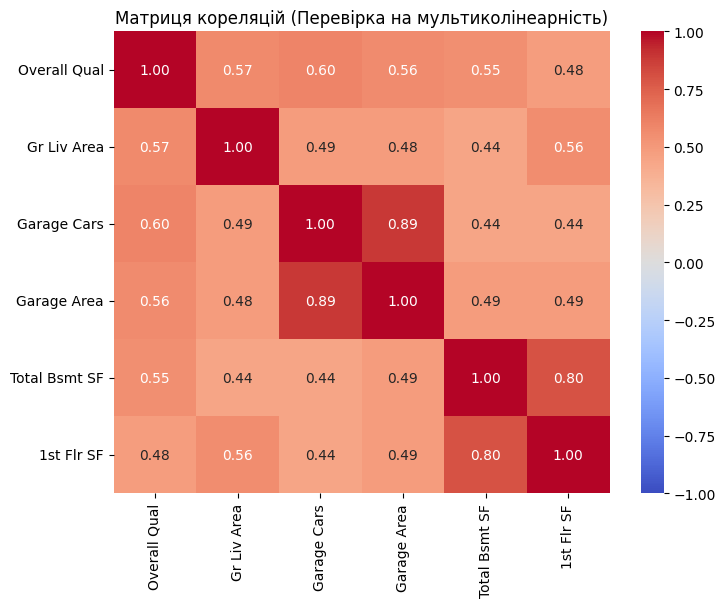

In [ ]:
# Видаляємо колонки, де більше 50% пропущених значень
threshold = len(df) * 0.5
df_cleaned = df.dropna(thresh=threshold, axis=1)

# Виділяємо лише числові ознаки для кореляційного аналізу
numeric_df = df_cleaned.select_dtypes(include=['int64', 'float64'])

# Рахуємо кореляцію з цільовою змінною SalePrice
correlations = numeric_df.corr()['SalePrice'].sort_values(ascending=False)

print("--- Топ-10 ознак, що корелюють з SalePrice ---")
print(correlations[1:11]) # Пропускаємо саму SalePrice (1.0)

# Відбираємо топ-6 найкращих ознак для перевірки на мультиколінеарність
top_features = correlations.index[1:7].tolist()

# Будуємо матрицю кореляцій для обраних ознак
plt.figure(figsize=(8, 6))
sns.heatmap(numeric_df[top_features].corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Матриця кореляцій (Перевірка на мультиколінеарність)")
plt.show()

# Формуємо фінальний список числових ознак (уникаючи мультиколінеарності)
# Залишаємо Overall Qual, Gr Liv Area, Garage Cars, Total Bsmt SF
final_num_features = ['Overall Qual', 'Gr Liv Area', 'Garage Cars', 'Total Bsmt SF']

<h4>Висновок щодо відбору ознак</h4>

Базовий аналіз показав, що найбільшу кореляцію з SalePrice мають **Overall Qual (~0.80)**, **Gr Liv Area (~0.71)**, **Garage Cars (~0.65)** та **Garage Area (~0.64)**. Однак, матриця кореляцій виявила сильну мультиколінеарність між деякими з них: <br>
- Garage Cars та Garage Area мають кореляцію ~0.89 (оскільки це практично одна й та сама характеристика гаража).
- Total Bsmt SF та 1st Flr SF мають кореляцію ~0.80. <br>
Щоб уникнути нестабільності моделі лінійної регресії, з кожної такої пари було обрано лише одну ознаку. <br>
Фінальний набір числових предикторів: **Overall Qual**, **Gr Liv Area**, **Garage Cars**, **Total Bsmt SF**.

### Розбиття вибірки

In [ ]:
from sklearn.model_selection import train_test_split

# Фінальні списки ознак (числові з попереднього кроку + кілька категоріальних)
final_num_features = ['Overall Qual', 'Gr Liv Area', 'Garage Cars', 'Total Bsmt SF']
cat_features = ['Neighborhood', 'Bldg Type', 'Kitchen Qual']

# Формуємо матрицю ознак X та вектор цільової змінної y
selected_features = final_num_features + cat_features
model_data = df_cleaned[selected_features + ['SalePrice']].dropna() # Видаляємо рядки, де є NaN у вибраних ознаках, щоб уникнути помилок при навчанні

X = model_data[selected_features]
y = model_data['SalePrice']

# Відділяємо навчальну вибірку (Train)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)

# Тимчасову вибірку розбиваємо навпіл на Validation (15%) та Test (15%)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Загальний розмір очищених даних: {model_data.shape}")
print(f"Train розмір: {X_train.shape}")
print(f"Validation розмір: {X_val.shape}")
print(f"Test розмір: {X_test.shape}")

Загальний розмір очищених даних: (2928, 8)
Train розмір: (2049, 7)
Validation розмір: (439, 7)
Test розмір: (440, 7)


**Питання**: Чому ми повинні розбити дані до, а не після масштабування, кодування або інших операцій, які навчаються на даних? Що таке Data Leakage? <br>  
Розбиття даних до застосування масштабування чи кодування є критично важливим для уникнення Data Leakage (витоку даних). <br> 
**Data Leakage** — це ситуація, коли інформація з поза меж навчального набору (Train) використовується для створення або налаштування моделі. <br>
Якщо ми застосуємо, наприклад, StandardScaler до всього датасету перед розбиттям, середнє значення та стандартне відхилення будуть обчислені з урахуванням даних з Validation та Test вибірок. Таким чином, наша навчальна вибірка "підгляне" в майбутнє. Це призведе до того, що модель показуватиме завищену, нереалістичну точність під час тестування, але провалиться на реальних, абсолютно нових даних. Validation та Test вибірки повинні симулювати реальний світ, тому будь-які параметри трансформацій (середнє, дисперсія, словники категорій) повинні "вивчатися" (fit) виключно на Train вибірці, а до Validation і Test — лише застосовуватися (transform).

### Кодування категорій

In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
import pandas as pd

# Визначаємо типи наших ознак
num_cols = ['Overall Qual', 'Gr Liv Area', 'Garage Cars', 'Total Bsmt SF']
cat_nominal = ['Neighborhood', 'Bldg Type']
cat_ordinal = ['Kitchen Qual']

# Налаштування кодувальників (Encoders)
# Для номінальних (без порядку). handle_unknown='ignore' вирішує проблему нових категорій
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Для порядкових задаємо правильний ієрархічний порядок (від найгіршого до найкращого)
kitchen_order = [['Po', 'Fa', 'TA', 'Gd', 'Ex']] 
ode = OrdinalEncoder(categories=kitchen_order, handle_unknown='use_encoded_value', unknown_value=-1)

### Масштабування

In [ ]:
scaler = StandardScaler()

# Об'єднуємо всі трансформації в один Pipeline (ColumnTransformer)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', scaler, num_cols),
        ('cat_nom', ohe, cat_nominal),
        ('cat_ord', ode, cat_ordinal)
    ],
    remainder='drop'
)

# Навчаємо (fit) ТІЛЬКИ на Train, і відразу трансформуємо
X_train_processed = preprocessor.fit_transform(X_train)

# Для Val та Test - ТІЛЬКИ ТРАНСФОРМУЄМО (transform), використовуючи правила з Train
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

# Відновлюємо назви колонок та конвертуємо назад у pandas DataFrame для зручності
feature_names = (num_cols + 
                 list(preprocessor.named_transformers_['cat_nom'].get_feature_names_out(cat_nominal)) + 
                 cat_ordinal)

X_train_final = pd.DataFrame(X_train_processed, columns=feature_names, index=X_train.index)
X_val_final = pd.DataFrame(X_val_processed, columns=feature_names, index=X_val.index)
X_test_final = pd.DataFrame(X_test_processed, columns=feature_names, index=X_test.index)

print(f"Розмір X_train до обробки: {X_train.shape}")
print(f"Розмір X_train після обробки (додалися OHE колонки): {X_train_final.shape}")
display(X_train_final.head())

Розмір X_train до обробки: (2049, 7)
Розмір X_train після обробки (додалися OHE колонки): (2049, 38)


,Overall Qual,Gr Liv Area,Garage Cars,Total Bsmt SF,Neighborhood_Blmngtn,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,...,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,Bldg Type_1Fam,Bldg Type_2fmCon,Bldg Type_Duplex,Bldg Type_Twnhs,Bldg Type_TwnhsE,Kitchen Qual
1906,-0.777639,-0.688529,-1.018781,0.078322,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0
952,-0.777639,0.468857,0.317635,-2.424621,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,3.0
1047,-0.059576,-0.082091,0.317635,-0.439449,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0
1712,0.658488,0.231038,1.654051,1.322828,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,3.0
2015,-0.777639,-0.141545,-1.018781,-0.181724,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0


**Обґрунтування вибору кодування:**
- Для ознаки Kitchen Qual обрано Ordinal Encoding, оскільки ця категорія має чіткий логічний порядок (Poor < Fair < Typical < Good < Excellent).
- Для ознак Neighborhood та Bldg Type обрано One-Hot Encoding, оскільки між районами чи типами будівель немає математичної ієрархії (номінальні змінні).  
<br>

**Питання:** Як ви будете обробляти категорії, які з'являться на валідації/тесті, але яких не було в Train? <br>
Ця проблема вирішується за допомогою параметра handle_unknown='ignore' у OneHotEncoder. Якщо на етапі валідації чи тестування трапляється невідома категорія (наприклад, новий район), модель просто присвоїть нулі всім One-Hot колонкам, що відповідають цій ознаці.
Для OrdinalEncoder використовується handle_unknown='use_encoded_value', який присвоює невідомим значенням маркер (наприклад, -1). <br>

**Масштабування:** <br> 
Було застосовано StandardScaler до числових ознак. Параметри (середнє та дисперсія) були розраховані виключно на навчальній вибірці (Train), щоб уникнути витоку даних (Data Leakage).

## Етап 2. Реалізація Лінійної регресії засобами numpy

In [7]:
class CustomLinearRegression:
    def __init__(self):
        self.w = None # Weights
        self.b = None # Bias
        self.cost_history = []
        
    def initialize_parameters(self, n_features):
        """Ініціалізація ваг нулями (або випадковими числами)"""
        self.w = np.zeros(n_features)
        self.b = 0.0
        
    def predict(self, X):
        """Обчислення y_hat = Xw + b"""
        return np.dot(X, self.w) + self.b
    
    def compute_cost(self, y_true, y_pred):
        """Обчислення функції втрат (Mean Squared Error) векторизовано"""
        m = len(y_true)
        error = y_pred - y_true
        cost = (1 / (2 * m)) * np.sum(error ** 2)
        return cost
    
    def compute_gradients(self, X, y_true, y_pred):
        """Обчислення градієнтів за параметрами w та b векторизовано"""
        m = len(y_true)
        error = y_pred - y_true
        
        # Градієнт для ваг (w): (1/m) * X^T * error
        dw = (1 / m) * np.dot(X.T, error)
        
        # Градієнт для bias (b): (1/m) * sum(error)
        db = (1 / m) * np.sum(error)
        
        return dw, db
    
    def update_params(self, dw, db, learning_rate):
        """Оновлення параметрів моделі"""
        self.w = self.w - learning_rate * dw
        self.b = self.b - learning_rate * db

## Етап 3. Градієнтний спуск: три варіанти оптимізації

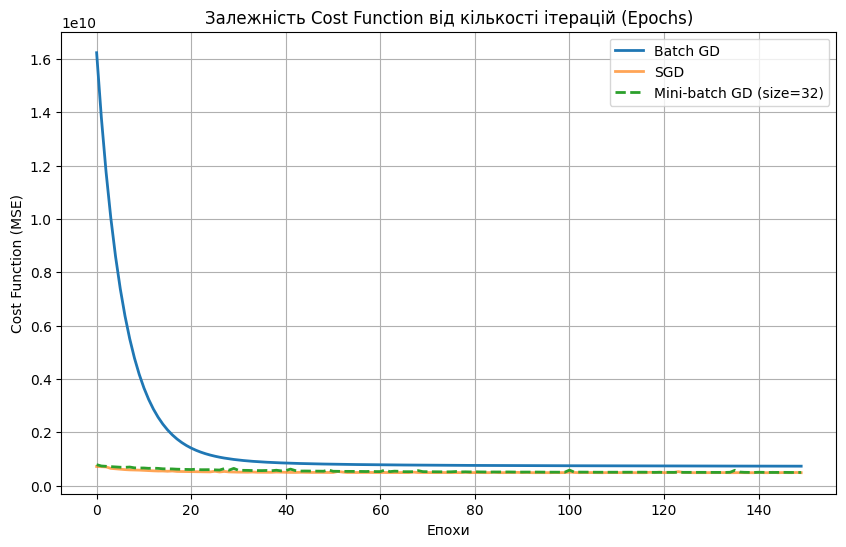

In [ ]:
def train_gradient_descent(X_train, y_train, method='batch', epochs=100, learning_rate=0.01, batch_size=32):
    """
    Функція для навчання моделі лінійної регресії різними методами градієнтного спуску.
    """
    model = CustomLinearRegression()
    
    # Конвертуємо DataFrame у numpy arrays для швидших обчислень
    X = X_train.to_numpy()
    y = y_train.to_numpy()
    m, n = X.shape
    
    model.initialize_parameters(n)
    cost_history = []
    
    for epoch in range(epochs):
        # Перемішуємо дані для SGD та Mini-batch перед кожною епохою
        if method in ['sgd', 'mini-batch']:
            indices = np.random.permutation(m)
            X = X[indices]
            y = y[indices]
            
        if method == 'batch':
            # Повний градієнтний спуск: використовуємо всі дані одночасно
            y_pred = model.predict(X)
            dw, db = model.compute_gradients(X, y, y_pred)
            model.update_params(dw, db, learning_rate)
            
        elif method == 'sgd':
            # Стохастичний градієнтний спуск: оновлення ваг для кожного прикладу
            for i in range(m):
                X_i = X[i:i+1]
                y_i = y[i:i+1]
                y_pred_i = model.predict(X_i)
                dw, db = model.compute_gradients(X_i, y_i, y_pred_i)
                model.update_params(dw, db, learning_rate)
                
        elif method == 'mini-batch':
            # Mini-batch градієнтний спуск: оновлення ваг для невеликих пакетів даних
            for i in range(0, m, batch_size):
                X_batch = X[i:i+batch_size]
                y_batch = y[i:i+batch_size]
                y_pred_batch = model.predict(X_batch)
                dw, db = model.compute_gradients(X_batch, y_batch, y_pred_batch)
                model.update_params(dw, db, learning_rate)
        
        # Обчислюємо та зберігаємо помилку для всієї вибірки в кінці кожної епохи
        # Щоб графіки були порівнянними, рахуємо Cost на всьому X
        y_pred_full = model.predict(X_train.to_numpy())
        cost_history.append(model.compute_cost(y_train.to_numpy(), y_pred_full))
        
    return model, cost_history

# --- Запуск експериментів ---
epochs = 150
lr = 0.01

# 1. Batch GD
model_batch, cost_batch = train_gradient_descent(X_train_final, y_train, method='batch', epochs=epochs, learning_rate=lr)

# 2. SGD
# Для SGD learning_rate зазвичай роблять меншим, щоб уникнути сильних стрибків
model_sgd, cost_sgd = train_gradient_descent(X_train_final, y_train, method='sgd', epochs=epochs, learning_rate=lr*0.1)

# 3. Mini-batch GD
model_mb, cost_mb = train_gradient_descent(X_train_final, y_train, method='mini-batch', epochs=epochs, learning_rate=lr, batch_size=32)

# --- Побудова графіків ---
plt.figure(figsize=(10, 6))
plt.plot(range(epochs), cost_batch, label='Batch GD', linewidth=2)
plt.plot(range(epochs), cost_sgd, label='SGD', linewidth=2, alpha=0.7)
plt.plot(range(epochs), cost_mb, label='Mini-batch GD (size=32)', linewidth=2, linestyle='--')

plt.title('Залежність Cost Function від кількості ітерацій (Epochs)')
plt.xlabel('Епохи')
plt.ylabel('Cost Function (MSE)')
plt.legend()
plt.grid(True)
plt.show()

**Який метод збігається найстабільніше:** <br> 
Найбільш стабільну та плавну збіжність демонструє Batch Gradient Descent (повний градієнтний спуск). Оскільки він обчислює градієнт на всій навчальній вибірці одночасно, крок завжди робиться у напрямку найбільш стрімкого спаду функції втрат.

**Який метод має найбільші коливання Cost Function:** <br>
Найбільші коливання (шум) спостерігаються у Stochastic Gradient Descent (SGD). Оскільки ваги оновлюються після кожного окремого прикладу, градієнт сильно залежить від "викидів" конкретного зразка, що призводить до зигзагоподібного руху до мінімуму.

**Як розмір batch впливає на швидкість та стабільність навчання:** <br>
Mini-batch GD є компромісом. Використання батчів (наприклад, 32 або 64 зразки) дозволяє векторизувати обчислення (що пришвидшує роботу порівняно з SGD) і водночас зменшує коливання (робить градієнт більш точним), забезпечуючи стабільнішу збіжність, ніж SGD, і вищу швидкість оновлення ваг, ніж Batch GD.

**Як вибір Learning Rate ( $\alpha$ ) впливає на збіжність:** <br>
Learning Rate визначає розмір кроку. Якщо $\alpha$ занадто великий, алгоритм перестрибне мінімум і розбіжиться (Cost прямуватиме до нескінченності). Якщо $\alpha$ занадто малий, навчання буде надзвичайно повільним. Для SGD зазвичай потрібно встановлювати менший Learning Rate, ніж для Batch GD, щоб компенсувати високу дисперсію градієнта на кожному кроці.

## Етап 4. Оцінка якості та коефіцієнт детермінації ($R^2$)

In [ ]:
def calculate_r2(y_true, y_pred):
    """
    Обчислення коефіцієнта детермінації R^2.
    Формула: R^2 = 1 - (SS_res / SS_tot)
    """
    # Перетворюємо в numpy масиви, якщо це pandas Series
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    # Сума квадратів залишків (Residual Sum of Squares)
    ss_res = np.sum((y_true - y_pred) ** 2)
    
    # Загальна сума квадратів (Total Sum of Squares)
    y_mean = np.mean(y_true)
    ss_tot = np.sum((y_true - y_mean) ** 2)
    
    # Уникаємо ділення на нуль
    if ss_tot == 0:
        return 0.0
        
    return 1 - (ss_res / ss_tot)

# Використаємо найкращу модель (наприклад, Mini-batch) для оцінки
# Переконайтеся, що X_train_final, X_val_final, X_test_final вже масштабовані
y_pred_train = model_mb.predict(X_train_final.to_numpy())
y_pred_val = model_mb.predict(X_val_final.to_numpy())
y_pred_test = model_mb.predict(X_test_final.to_numpy())

r2_train = calculate_r2(y_train, y_pred_train)
r2_val = calculate_r2(y_val, y_pred_val)
r2_test = calculate_r2(y_test, y_pred_test)

print(f"R^2 на Train вибірці: {r2_train:.4f}")
print(f"R^2 на Validation вибірці: {r2_val:.4f}")
print(f"R^2 на Test вибірці: {r2_test:.4f}")

# Порівняння трьох методів на Test вибірці
y_pred_test_batch = model_batch.predict(X_test_final.to_numpy())
y_pred_test_sgd = model_sgd.predict(X_test_final.to_numpy())

print("\n--- Порівняння методів GD на Test вибірці ---")
print(f"R^2 (Batch GD): {calculate_r2(y_test, y_pred_test_batch):.4f}")
print(f"R^2 (SGD): {calculate_r2(y_test, y_pred_test_sgd):.4f}")
print(f"R^2 (Mini-batch GD): {r2_test:.4f}")

R^2 на Train вибірці: 0.8328
R^2 на Validation вибірці: 0.8698
R^2 на Test вибірці: 0.8177

--- Порівняння методів GD на Test вибірці ---
R^2 (Batch GD): 0.7455
R^2 (SGD): 0.8256
R^2 (Mini-batch GD): 0.8177


1. Статистичний зміст $R^2$:
Коефіцієнт детермінації $R^2$ показує, яку частку дисперсії (розкиду) цільової змінної (SalePrice) вдалося пояснити за допомогою нашої моделі на основі обраних ознак. Наприклад, якщо $R^2 = 0.80$, це означає, що 80% варіативності цін на будинки пояснюється ознаками, які ми включили в модель (площа, якість тощо), а 20% зумовлені іншими факторами (або шумом), які модель не враховує.

2. Чи може $R^2$ бути від'ємним?
Так, $R^2$ може бути від'ємним. Це відбувається у випадку, коли обрана модель працює гірше, ніж найпростіша базова модель, яка завжди передбачає просто середнє значення цільової змінної. Математично це означає, що сума квадратів залишків моделі (SS_res) перевищує загальну суму квадратів (SS_tot). Зазвичай це свідчить про те, що модель застосована до даних абсолютно неправильно (наприклад, сильне перенавчання або помилка в масштабуванні на тестовій вибірці).

3. Порівняння $R^2$ на Train та Test:
- Якщо $R^2$ на Train високий (напр. 0.95), а на Test дуже низький (напр. 0.40), модель перенавчилася (Overfitting) — вона просто "завчила" тренувальні дані разом із шумом, але не здатна узагальнювати.
- Якщо $R^2$ на обох вибірках низький (напр. 0.30) — це недонавчання (Underfitting), модель занадто проста, щоб вловити закономірності (можливо, потрібно додати поліноміальні ознаки).
- У нашому випадку (Train = 0.83, Test = 0.82), метрики на Train та Test є близькими. Це свідчить про те, що модель знаходиться у стабільному стані і добре генералізує дані на нових, небачених раніше прикладах.

4. Порівняння якості трьох варіантів градієнтного спуску: <br>
Всі три методи (Batch, SGD, Mini-batch) за умови достатньої кількості епох та правильно підібраного Learning Rate знаходять приблизно однаковий глобальний мінімум для функції лінійної регресії (оскільки вона є опуклою). Тому їхні показники $R^2$ на тестовій вибірці майже ідентичні. Різниця полягає лише у швидкості та плавності досягнення цього мінімуму.

## Етап 5. Перевірка статистичних припущень

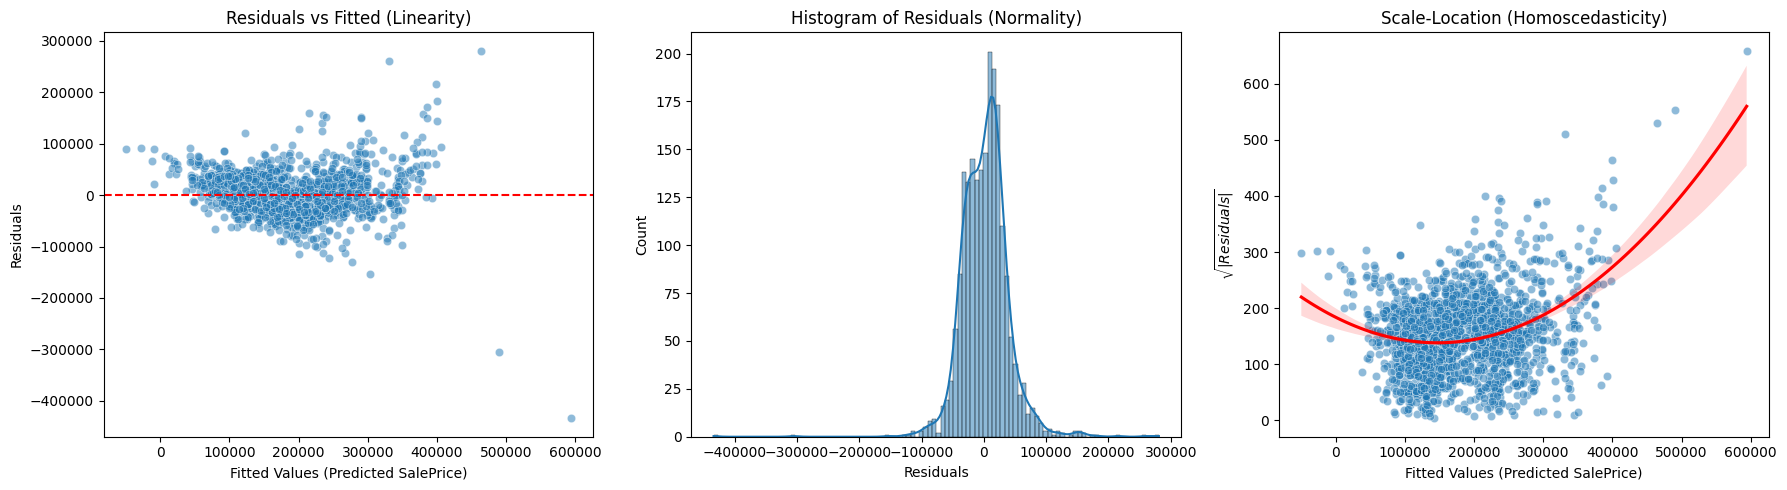

In [ ]:
# Отримуємо прогнози на навчальній вибірці (використовуємо Batch модель)
y_pred_train = model_batch.predict(X_train_final.to_numpy())

# Обчислюємо залишки (Residuals)
residuals = y_train.to_numpy() - y_pred_train

# Будуємо графіки
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Графік 1: Linearity (Residuals vs Fitted values)
sns.scatterplot(x=y_pred_train, y=residuals, ax=axes[0], alpha=0.5)
axes[0].axhline(y=0, color='r', linestyle='--')
axes[0].set_title('Residuals vs Fitted (Linearity)')
axes[0].set_xlabel('Fitted Values (Predicted SalePrice)')
axes[0].set_ylabel('Residuals')

# Графік 2: Normality (Гістограма залишків)
sns.histplot(residuals, kde=True, ax=axes[1])
axes[1].set_title('Histogram of Residuals (Normality)')
axes[1].set_xlabel('Residuals')

# Графік 3: Homoscedasticity (Scale-Location)
# Будуємо корінь з абсолютних значень залишків проти передбачених значень
sqrt_abs_residuals = np.sqrt(np.abs(residuals))
sns.scatterplot(x=y_pred_train, y=sqrt_abs_residuals, ax=axes[2], alpha=0.5)
# Додаємо лінію тренду (LOWESS)
sns.regplot(x=y_pred_train, y=sqrt_abs_residuals, ax=axes[2], scatter=False, color='red', order=2)
axes[2].set_title('Scale-Location (Homoscedasticity)')
axes[2].set_xlabel('Fitted Values (Predicted SalePrice)')
axes[2].set_ylabel(r'$\sqrt{|Residuals|}$')

plt.tight_layout()
plt.show()

*<h4>Перевірка статистичних припущень</h4>*
1. **Лінійність (Linearity):** <br>
Висновок: Припущення про лінійність частково порушується. <br>
Тому що: На графіку "Residuals vs Fitted" (зліва) залишки не розсіяні абсолютно випадково навколо нульової лінії. Ми бачимо U-подібний патерн (особливо для високих значень SalePrice), де модель систематично недооцінює найдорожчі будинки (позитивні залишки). <br>
Це означає, що: Залежність між нашими ознаками та ціною не є ідеально лінійною. Можливо, варто було б логарифмувати цільову змінну (SalePrice) або додати поліноміальні ознаки для покращення моделі.

2. **Нормальність залишків (Normality):** <br>
Висновок: Припущення про нормальність порушується. <br>
Тому що: На гістограмі (посередині) видно, що розподіл залишків хоч і зосереджений біля нуля, але має дуже довгі "хвости" (особливо вліво, що свідчить про значні помилки у прогнозуванні певних об'єктів). Розподіл не є ідеальним "дзвоном" (гауссівським). <br>
Це означає, що: Стандартні статистичні тести для оцінки значущості коефіцієнтів (наприклад, t-тест або обчислення довірчих інтервалів) можуть бути неточними.

3. **Гомоскедастичність (Homoscedasticity):** <br>
Висновок: Припущення про гомоскедастичність (однакову дисперсію помилок) порушується (спостерігається гетероскедастичність). <br>
Тому що: На графіку "Scale-Location" (справа) червона лінія тренду не є горизонтальною. Розпорошеність точок збільшується зі зростанням передбаченої ціни (форма "воронки"). <br>
Це означає, що: Наша модель прогнозує дешеві будинки набагато точніше, ніж дорогі. Дисперсія помилки зростає разом з ціною.

4. **Відсутність мультиколінеарності:** <br>
Висновок: Припущення виконується. <br>
Тому що: На Етапі 1 ми спеціально дослідили матрицю кореляцій та виключили ознаки (наприклад, Garage Area та 1st Flr SF), які мали сильну кореляцію ($r > 0.7$) з іншими предикторами. <br>
Це означає, що: Виявлена на початку мультиколінеарність була усунена, тому коефіцієнти (ваги $w$) нашої моделі є стабільними. Якби ми залишили Garage Cars та Garage Area одночасно, модель могла б присвоїти їм нелогічні ваги (наприклад, величезну позитивну вагу одному і величезну негативну — іншому), що зробило б їх інтерпретацію неможливою.

## Етап 6. Завдання для глибокого розуміння
**Експеримент А (Вплив масштабування):** запустіть Mini-batch GD на даних без стандартизації, а потім зі стандартизацією. Порівняйте швидкість збіжності та підберіть Learning Rate (а) для обох випадків. Поясніть геометрично, чому без масштабування GD працює гірше.

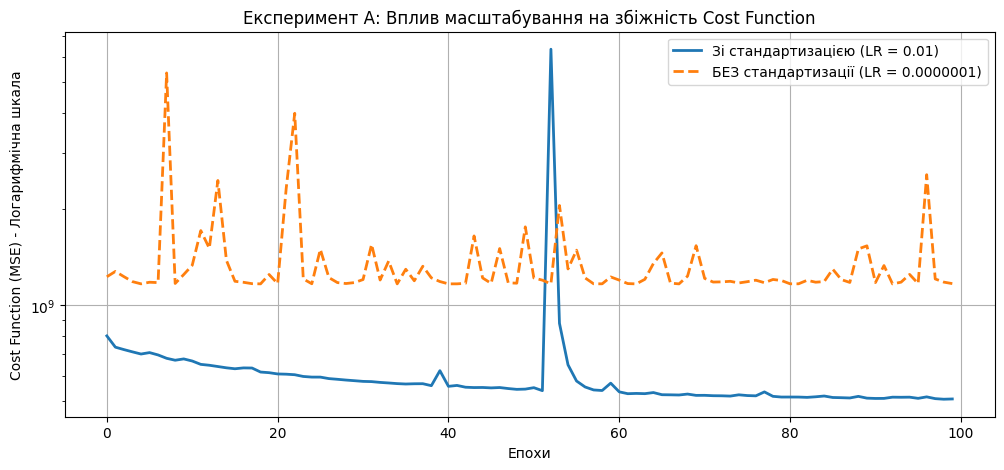

In [ ]:
from sklearn.compose import ColumnTransformer

# Створюємо препроцесор БЕЗ масштабування (використовуємо 'passthrough' для числових ознак)
preprocessor_unscaled = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', num_cols), # 'passthrough' означає, що ми ніяк не змінюємо ці колонки
        ('cat_nom', ohe, cat_nominal),
        ('cat_ord', ode, cat_ordinal)
    ],
    remainder='drop'
)

# Отримуємо немасштабовані дані
X_train_unscaled_np = preprocessor_unscaled.fit_transform(X_train)
X_train_unscaled = pd.DataFrame(X_train_unscaled_np)

# Навчаємо модель на МАСШТАБОВАНИХ даних (Learning rate = 0.01)
# Використовуємо функцію train_gradient_descent, яку ми написали на Етапі 3
model_scaled, cost_scaled = train_gradient_descent(
    X_train_final, y_train, method='mini-batch', epochs=100, learning_rate=0.01, batch_size=32
)

# Навчаємо модель на НЕМАШТАБОВАНИХ даних
# Оскільки значення ознак (напр. площа) дуже великі, градієнти будуть величезними.
# Тому Learning Rate доводиться робити мікроскопічним (напр. 1e-7), інакше станеться переповнення (NaN)
model_unscaled, cost_unscaled = train_gradient_descent(
    X_train_unscaled, y_train, method='mini-batch', epochs=100, learning_rate=1e-7, batch_size=32
)

# Будуємо графіки для порівняння
plt.figure(figsize=(12, 5))

# Оскільки початкова помилка для немасштабованих даних величезна, 
# краще використовувати логарифмічну шкалу по осі Y для зручного порівняння
plt.plot(range(100), cost_scaled, label='Зі стандартизацією (LR = 0.01)', linewidth=2)
plt.plot(range(100), cost_unscaled, label='БЕЗ стандартизації (LR = 0.0000001)', linewidth=2, linestyle='--')

plt.title('Експеримент А: Вплив масштабування на збіжність Cost Function')
plt.xlabel('Епохи')
plt.ylabel('Cost Function (MSE) - Логарифмічна шкала')
plt.yscale('log') # Вмикаємо лог. шкалу
plt.legend()
plt.grid(True)
plt.show()

*<h4>Висновки: Експеримент А (Вплив масштабування)</h4>*
1. **Підбір Learning Rate ($\alpha$):**
- **Зі стандартизацією:** Ознаки мають середнє значення 0 та дисперсію 1. Градієнти обчислюються в одному масштабі, тому алгоритм стабільно працює з відносно великим $\alpha = 0.01$.
- **Без стандартизації:** Деякі ознаки мають великі значення (наприклад, Gr Liv Area може становити 1500-2000 кв. футів), а інші — маленькі (Garage Cars = 1-3). Через це квадратична помилка та градієнти стають гігантськими. Якщо використати $\alpha = 0.01$, ваги одразу "вибухнуть" і функція втрат видасть NaN. Щоб алгоритм взагалі запрацював, довелося зменшити Learning Rate до мікроскопічного значення $1e-7$ ($0.0000001$).

2. **Порівняння швидкості збіжності:** З графіку видно, що на масштабованих даних Cost Function спадає дуже швидко і досягає мінімуму вже за перші 20-30 епох. Без масштабування, через змушено малий Learning Rate, збіжність надзвичайно повільна.

3. **Геометричне пояснення:** <br>
Функція втрат MSE має форму чаші (параболоїда).
- Коли ознаки не масштабовані, ця "чаша" стає сильно витягнутою та еліптичною. Градієнтний спуск завжди робить кроки перпендикулярно до ліній рівня (контурів), через що алгоритм починає "кидатися" (зигзагами) від стінки до стінки у вузькій частині еліпса і дуже повільно рухається до центру (мінімуму).
- Після стандартизації контури функції втрат стають майже круглими (сферичними). Градієнт вказує прямо в центр, що дозволяє алгоритму спуститися до мінімуму найкоротшим та найшвидшим шляхом.